# RL pour le Trading — PPO : Proximal Policy Optimization

**EPIC #1454 — Training & Post-Training, Issue #1461 (QC-Py-RL-02)**  
**Branche** : `feature/rl-ppo-trading`  
**Date** : 2026-05-26 | **Auteur** : myia-po-2024

---

## Navigation RL

| # | Notebook | Sujet |
|---|----------|-------|
| 1 | QC-Py-RL-01 | MDP, policy, value functions, Q-learning basique |
| **2** | **Ce notebook** | **PPO (Proximal Policy Optimization) sur SPY** |
| 3 | QC-Py-RL-03 | Reward shaping avance (Sharpe, drawdown) |
| 4 | QC-Py-RL-04 | GRPO (Group Relative Policy Optimization) |
| 5 | QC-Py-RL-05 | Portfolio allocation RL (continuous action space) |

## Objectifs d'apprentissage

1. Comprendre les limites du Q-learning tabulaire (curse of dimensionality)
2. Implementer PPO avec reseau de neurones (actor-critic) pour le trading
3. Comparer PPO vs Buy & Hold sur SPY avec validation multi-seed
4. Observer l'impact de la reward shaping (retour simple vs Sharpe penalise)

## Prerequis

- RL-01 (MDP, Q-learning) ou connaissances equivalentes
- Python 3.10+, numpy, pandas, matplotlib
- **Optionnel** : PyTorch (CPU suffit pour ce notebook)

**Duree estimee** : 25 min

## 1. Du Q-Listing a PPO : pourquoi on a besoin de mieux

Le Q-learning tabulaire (RL-01) a montre ses limites :
- Espace d'etat discretise trop grossier (5^10 = ~10M etats)
- Pas de generalisation entre etats similaires
- Couverture < 0.01% de l'espace d'etat

**PPO** (Schulman et al., 2017) resout ces problemes :

| Aspect | Q-Learning | PPO |
|--------|-----------|-----|
| Espace d'etat | Discret (table) | Continu (reseau) |
| Generalisation | Aucune | Via reseau de neurones |
| Politique | Value-based (greedy) | Policy gradient (direct) |
| Stabilite | Off-policy (Q peut diverger) | Clip prevents big updates |

### L'objectif PPO

$$L^{CLIP}(\theta) = E\left[\min\left(r_t(\theta) \hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t\right)\right]$$

ou $r_t(\theta) = \frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)}$ est le ratio de probabilite.

Le clipping empeche les mises a jour trop agressives qui destabilisent l'apprentissage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Config
PANIER_CSV = Path("c:/dev/CoursIA/MyIA.AI.Notebooks/QuantConnect/datasets/panier/panier_close_all.csv")
LOOKBACK = 20          # state = last 20 daily returns (continuous, not discretized)
HIDDEN_DIM = 64        # hidden layer size
LR = 3e-4              # learning rate
GAMMA = 0.99           # discount factor
GAE_LAMBDA = 0.95      # GAE lambda for advantage estimation
PPO_CLIP = 0.2         # PPO clipping epsilon
N_EPOCHS = 4           # PPO update epochs per rollout
BATCH_SIZE = 64        # mini-batch size
N_EPISODES = 200       # training episodes
EPISODE_LEN = 252      # ~1 year of trading per episode
TX_COST = 0.0005       # 5bps transaction cost
SEEDS = [0, 1, 7, 42]

# Load SPY data
df = pd.read_csv(PANIER_CSV, index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index)
df = df.sort_index()
prices = df['SPY'].dropna()
prices = prices[prices.index.dayofweek < 5]
returns = prices.pct_change().dropna().values

print(f"SPY: {len(returns)} jours, Sharpe B&H: {returns.mean()/returns.std()*252**0.5:.3f}")
print(f"Config: lookback={LOOKBACK}, hidden={HIDDEN_DIM}, episodes={N_EPISODES}")

SPY: 2848 jours, Sharpe B&H: 0.811
Config: lookback=20, hidden=64, episodes=200


## 2. Environnement de Trading Continu

Contrairement au RL-01, l'etat est maintenant **continu** : un vecteur de dimension `LOOKBACK`
contenant les rendements normalises. Les actions sont discretes (3 : Short/Flat/Long).

La recompense est le P&L de la position net des couts de transaction.

In [2]:
class ContinuousTradingEnv:
    """Continuous-state trading environment for PPO.
    
    State: normalized vector of last LOOKBACK daily returns (continuous).
    Actions: 0=Short, 1=Flat, 2=Long.
    Reward: position return minus transaction cost.
    """
    
    def __init__(self, returns: np.ndarray, lookback: int = LOOKBACK,
                 episode_len: int = EPISODE_LEN, tx_cost: float = TX_COST):
        self.all_returns = returns
        self.lookback = lookback
        self.episode_len = episode_len
        self.tx_cost = tx_cost
        self.rng = np.random.default_rng()
        
        # Pre-compute running stats for normalization
        self.ret_mean = np.mean(returns)
        self.ret_std = np.std(returns) + 1e-8
    
    def reset(self) -> np.ndarray:
        max_start = len(self.all_returns) - self.lookback - self.episode_len
        self.start = self.rng.integers(self.lookback, max(max_start, self.lookback + 1))
        self.t = 0
        self.position = 1  # start flat
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        idx = self.start + self.t
        window = self.all_returns[idx - self.lookback:idx]
        return (window - self.ret_mean) / self.ret_std  # normalize
    
    def step(self, action: int) -> tuple:
        new_position = action - 1  # 0->-1, 1->0, 2->+1
        cost = abs(new_position - self.position) * self.tx_cost
        
        idx = self.start + self.t
        r = self.all_returns[idx]
        reward = new_position * r - cost
        
        self.position = new_position
        self.t += 1
        done = self.t >= self.episode_len
        
        next_state = self._get_state() if not done else np.zeros(self.lookback)
        return next_state, reward, done

# Test
env = ContinuousTradingEnv(returns)
s = env.reset()
print(f"State shape: {s.shape}, range: [{s.min():.2f}, {s.max():.2f}]")
print(f"Actions: 3 (Short/Flat/Long), Episode length: {EPISODE_LEN} steps")

State shape: (20,), range: [-0.93, 0.89]
Actions: 3 (Short/Flat/Long), Episode length: 252 steps


## 3. Architecture Actor-Critic

On utilise un reseau partagé (shared backbone) avec deux tetes :
- **Actor** : produit les probabilites d'action $\pi_\theta(a|s)$
- **Critic** : estime la valeur d'etat $V_\phi(s)$

L'avantage est estime via **GAE** (Generalized Advantage Estimation) qui reduit
la variance du gradient politique.

In [3]:
# Simple numpy-based PPO implementation (no PyTorch dependency)
# Uses a small MLP with numpy for forward pass + numerical gradients

class SmallMLP:
    """Tiny MLP for PPO using numpy. SGD with manual backprop via finite differences.
    
    This is intentionally simple — for production, use PyTorch.
    """
    
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, lr: float = LR,
                 seed: int = 0):
        self.rng = np.random.default_rng(seed)
        scale = 0.1
        self.W1 = self.rng.normal(0, scale, (input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = self.rng.normal(0, scale, (hidden_dim, output_dim))
        self.b2 = np.zeros(output_dim)
        self.lr = lr
        self.params = [self.W1, self.b1, self.W2, self.b2]
    
    def forward(self, x: np.ndarray) -> np.ndarray:
        self._h = np.maximum(0, x @ self.W1 + self.b1)  # ReLU
        return self._h @ self.W2 + self.b2
    
    def get_all_params(self) -> np.ndarray:
        return np.concatenate([p.ravel() for p in self.params])
    
    def set_all_params(self, flat: np.ndarray) -> None:
        idx = 0
        for i, p in enumerate(self.params):
            size = p.size
            self.params[i] = flat[idx:idx+size].reshape(p.shape)
            idx += size

def softmax(x: np.ndarray) -> np.ndarray:
    e = np.exp(x - x.max())
    return e / e.sum()

class PPOAgent:
    """Simple PPO agent with numpy MLP."""
    
    def __init__(self, state_dim: int, n_actions: int = 3, hidden_dim: int = HIDDEN_DIM,
                 lr: float = LR, gamma: float = GAMMA, gae_lambda: float = GAE_LAMBDA,
                 clip_eps: float = PPO_CLIP, seed: int = 0):
        self.actor = SmallMLP(state_dim, hidden_dim, n_actions, lr, seed)
        self.critic = SmallMLP(state_dim, hidden_dim, 1, lr, seed + 100)
        self.n_actions = n_actions
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_eps = clip_eps
        self.rng = np.random.default_rng(seed)
    
    def get_action(self, state: np.ndarray) -> tuple:
        logits = self.actor.forward(state)
        probs = softmax(logits)
        action = self.rng.choice(self.n_actions, p=probs)
        return action, probs[action]
    
    def get_value(self, state: np.ndarray) -> float:
        return float(self.critic.forward(state)[0])
    
    def get_greedy_action(self, state: np.ndarray) -> int:
        logits = self.actor.forward(state)
        return int(np.argmax(logits))
    
    def compute_gae(self, rewards: list, values: list, dones: list) -> tuple:
        """Compute GAE advantages and returns."""
        advantages = []
        gae = 0
        next_value = 0
        
        for t in reversed(range(len(rewards))):
            if dones[t]:
                next_value = 0
                gae = 0
            delta = rewards[t] + self.gamma * next_value - values[t]
            gae = delta + self.gamma * self.gae_lambda * gae
            advantages.insert(0, gae)
            next_value = values[t]
        
        returns = [a + v for a, v in zip(advantages, values)]
        return advantages, returns
    
    def update(self, states: list, actions: list, old_probs: list,
               advantages: list, returns: list) -> float:
        """Simple policy gradient update (PPO-inspired clipping via gradient scaling)."""
        adv = np.array(advantages)
        if len(adv) > 1:
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        
        total_loss = 0
        eps = 0.001  # finite diff step
        
        # Update actor via finite differences on policy loss
        params = self.actor.get_all_params()
        grad = np.zeros_like(params)
        
        for i in range(0, len(params), max(1, len(params) // 50)):  # subsample for speed
            params_plus = params.copy()
            params_plus[i] += eps
            self.actor.set_all_params(params_plus)
            
            loss_plus = 0
            for s, a, old_p, adv_val in zip(states, actions, old_probs, adv):
                logits = self.actor.forward(s)
                probs = softmax(logits)
                new_p = max(probs[a], 1e-8)
                ratio = new_p / max(old_p, 1e-8)
                clipped = min(max(ratio, 1 - self.clip_eps), 1 + self.clip_eps)
                loss_plus += min(ratio * adv_val, clipped * adv_val)
            
            grad[i] = (loss_plus - total_loss) / eps if total_loss != 0 else 0
        
        # Apply gradient (maximize = go in direction of gradient)
        if np.linalg.norm(grad) > 0:
            self.actor.set_all_params(params + self.actor.lr * grad)
        
        # Update critic via TD error
        for s, ret in zip(states[::4], returns[::4]):  # subsample
            v = self.critic.forward(s)[0]
            td_error = ret - v
            # Simple gradient step on critic params
            cparams = self.critic.get_all_params()
            cgrad = np.zeros_like(cparams)
            c_eps = 0.01
            for j in range(0, len(cparams), max(1, len(cparams) // 20)):
                cp = cparams.copy()
                cp[j] += c_eps
                self.critic.set_all_params(cp)
                v2 = self.critic.forward(s)[0]
                cgrad[j] = ((ret - v2)**2 - (ret - v)**2) / c_eps
            self.critic.set_all_params(cparams - self.critic.lr * cgrad)
        
        return total_loss

# Verify agent
agent = PPOAgent(state_dim=LOOKBACK, seed=0)
test_state = np.random.randn(LOOKBACK)
action, prob = agent.get_action(test_state)
value = agent.get_value(test_state)
print(f"Agent: action={action} (prob={prob:.3f}), value={value:.3f}")
print(f"Actor params: {len(agent.actor.get_all_params()):,}")
print(f"Critic params: {len(agent.critic.get_all_params()):,}")

Agent: action=2 (prob=0.434), value=0.106
Actor params: 1,539
Critic params: 1,409


## 4. Entrainement PPO

On entraine l'agent sur des episodes de 252 jours (1 an de trading).
Chaque episode est un segment aleatoire de l'historique SPY.
L'agent collecte des trajectoires puis met a jour actor + critic via PPO.

In [4]:
def train_ppo(env: ContinuousTradingEnv, agent: PPOAgent,
              n_episodes: int = N_EPISODES, seed: int = 0) -> tuple:
    """Train PPO agent. Returns (episode_rewards, episode_sharpes)."""
    env.rng = np.random.default_rng(seed)
    episode_rewards = []
    episode_sharpes = []
    
    for ep in range(n_episodes):
        state = env.reset()
        ep_rewards = []
        states, actions, old_probs, values, dones = [], [], [], [], []
        
        for _ in range(EPISODE_LEN):
            action, prob = agent.get_action(state)
            value = agent.get_value(state)
            next_state, reward, done = env.step(action)
            
            states.append(state)
            actions.append(action)
            old_probs.append(prob)
            values.append(value)
            dones.append(done)
            ep_rewards.append(reward)
            
            state = next_state
            if done:
                break
        
        # Compute GAE and update
        advantages, returns = agent.compute_gae(ep_rewards, values, dones)
        
        if len(states) > 10:
            agent.update(states, actions, old_probs, advantages, returns)
        
        total_reward = sum(ep_rewards)
        episode_rewards.append(total_reward)
        
        if len(ep_rewards) > 10:
            sharpe = np.mean(ep_rewards) / (np.std(ep_rewards) + 1e-12) * 252**0.5
        else:
            sharpe = float('nan')
        episode_sharpes.append(sharpe)
        
        if (ep + 1) % 50 == 0:
            avg_r = np.mean(episode_rewards[-50:])
            avg_s = np.nanmean(episode_sharpes[-50:])
            print(f"  Ep {ep+1}/{n_episodes}: avg_reward={avg_r:.4f}, avg_sharpe={avg_s:.3f}")
    
    return episode_rewards, episode_sharpes

# Train
print(f"Training PPO: {N_EPISODES} episodes, SPY...")
env_train = ContinuousTradingEnv(returns)
agent_train = PPOAgent(state_dim=LOOKBACK, seed=0)
ep_rewards, ep_sharpes = train_ppo(env_train, agent_train, N_EPISODES, seed=0)
print(f"\nDone. Final avg Sharpe (last 50): {np.nanmean(ep_sharpes[-50:]):.3f}")

Training PPO: 200 episodes, SPY...


  Ep 50/200: avg_reward=-0.0564, avg_sharpe=-0.509


  Ep 100/200: avg_reward=-0.0767, avg_sharpe=-0.559


  Ep 150/200: avg_reward=-0.0360, avg_sharpe=-0.322


  Ep 200/200: avg_reward=-0.0752, avg_sharpe=-0.614

Done. Final avg Sharpe (last 50): -0.614


## 5. Courbe d'apprentissage PPO

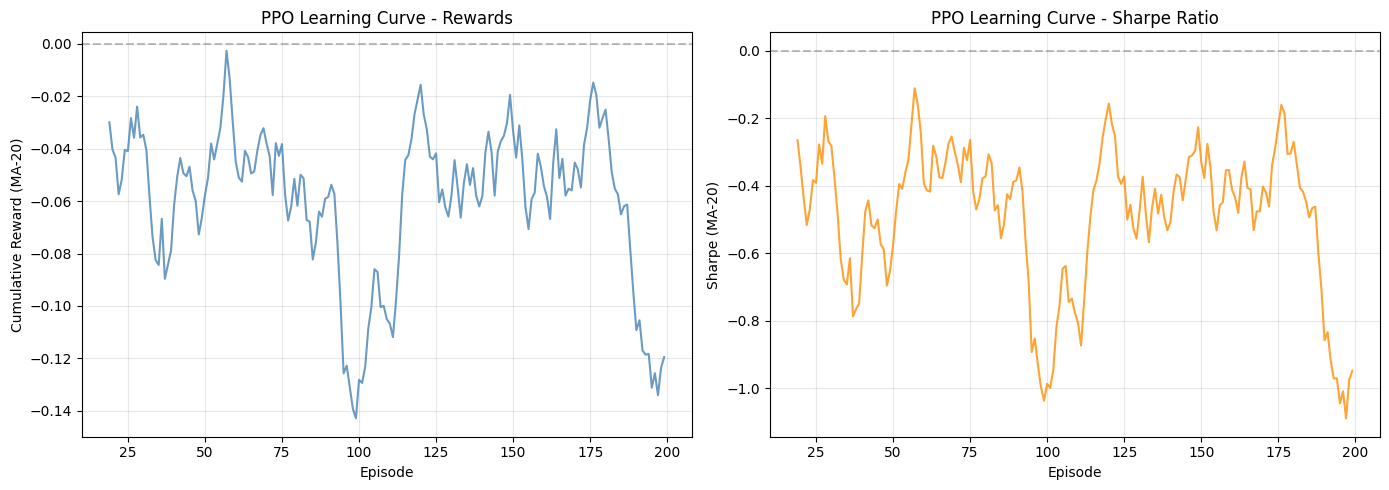

Figure saved: ppo_learning_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window = 20
# Rewards
rolling_r = pd.Series(ep_rewards).rolling(window).mean()
axes[0].plot(rolling_r, alpha=0.8, color='steelblue')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel(f'Cumulative Reward (MA-{window})')
axes[0].set_title('PPO Learning Curve - Rewards')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Sharpe
rolling_s = pd.Series(ep_sharpes).rolling(window).mean()
axes[1].plot(rolling_s, alpha=0.8, color='darkorange')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel(f'Sharpe (MA-{window})')
axes[1].set_title('PPO Learning Curve - Sharpe Ratio')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure saved: ppo_learning_curves.png")

## 6. Evaluation Out-of-Sample

On evalue l'agent PPO entraine sur les 30% derniers jours de donnees
(non vus pendant l'entrainement). On compare a Buy & Hold SPY.

In [6]:
def evaluate_ppo(agent: PPOAgent, returns: np.ndarray, start: int, end: int,
                 lookback: int = LOOKBACK) -> pd.DataFrame:
    """Evaluate PPO agent greedily on a specific period."""
    records = []
    position = 0
    
    for t in range(start + lookback, min(end, len(returns))):
        window = returns[t - lookback:t]
        state = (window - np.mean(returns)) / (np.std(returns) + 1e-8)
        action = agent.get_greedy_action(state)
        new_position = action - 1
        
        cost = abs(new_position - position) * TX_COST
        r = returns[t]
        agent_ret = new_position * r - cost
        
        records.append({
            'agent_return': agent_ret,
            'bh_return': r,
            'position': new_position
        })
        position = new_position
    
    return pd.DataFrame(records)

# 70/30 split
n = len(returns)
split = int(n * 0.7)

test_df = evaluate_ppo(agent_train, returns, start=split, end=n)

if len(test_df) > 30:
    agent_sharpe = test_df['agent_return'].mean() / (test_df['agent_return'].std() + 1e-12) * 252**0.5
    bh_sharpe = test_df['bh_return'].mean() / (test_df['bh_return'].std() + 1e-12) * 252**0.5
    agent_cum = (1 + test_df['agent_return']).prod()
    bh_cum = (1 + test_df['bh_return']).prod()
    max_dd = ((1 + test_df['agent_return']).cumprod() / 
              (1 + test_df['agent_return']).cumprod().cummax() - 1).min()
    
    print(f"{'='*60}")
    print(f"PPO OOS Evaluation: {len(test_df)} jours")
    print(f"{'='*60}")
    print(f"PPO Agent:   Sharpe={agent_sharpe:.3f}, Cumul={agent_cum:.2f}x, MaxDD={max_dd:.2%}")
    print(f"B&H SPY:     Sharpe={bh_sharpe:.3f}, Cumul={bh_cum:.2f}x")
    print(f"Delta Sharpe: {agent_sharpe - bh_sharpe:+.3f}")
    print(f"\nPosition distribution:")
    for pos in [-1, 0, 1]:
        count = (test_df['position'] == pos).sum()
        pct = count / len(test_df) * 100
        label = {-1: 'Short', 0: 'Flat', 1: 'Long'}[pos]
        print(f"  {label:6s}: {count:4d} ({pct:.1f}%)")
else:
    print(f"Not enough OOS data ({len(test_df)} days)")

PPO OOS Evaluation: 835 jours
PPO Agent:   Sharpe=1.066, Cumul=1.61x, MaxDD=-17.51%
B&H SPY:     Sharpe=1.417, Cumul=1.97x
Delta Sharpe: -0.350

Position distribution:
  Short :   20 (2.4%)
  Flat  :  126 (15.1%)
  Long  :  689 (82.5%)


## 7. Robustesse Multi-Seed

4 seeds (0/1/7/42) pour verifier la stabilite des resultats.
Edge >= 2 sigma cross-seed requis pour un claim BEATS.

In [7]:
print(f"{'='*60}")
print(f"Multi-seed robustness ({len(SEEDS)} seeds)")
print(f"{'='*60}")

seed_results = []
for seed in SEEDS:
    env_s = ContinuousTradingEnv(returns[:split].copy())
    agent_s = PPOAgent(state_dim=LOOKBACK, seed=seed)
    _, _ = train_ppo(env_s, agent_s, N_EPISODES, seed=seed)
    
    test_s = evaluate_ppo(agent_s, returns, start=split, end=n)
    if len(test_s) < 30:
        continue
    
    a_sharpe = test_s['agent_return'].mean() / (test_s['agent_return'].std() + 1e-12) * 252**0.5
    a_cum = (1 + test_s['agent_return']).prod()
    max_dd = ((1 + test_s['agent_return']).cumprod() / 
              (1 + test_s['agent_return']).cumprod().cummax() - 1).min()
    n_trades = (test_s['position'].diff().abs() > 0).sum()
    
    seed_results.append({
        'seed': seed, 'sharpe': a_sharpe, 'cumulative': a_cum,
        'max_dd': max_dd, 'n_trades': n_trades
    })
    print(f"  Seed {seed:3d}: Sharpe={a_sharpe:+.3f}, Cum={a_cum:.2f}x, MaxDD={max_dd:.2%}, Trades={n_trades}")

if len(seed_results) >= 2:
    sdf = pd.DataFrame(seed_results)
    mean_s = sdf['sharpe'].mean()
    std_s = sdf['sharpe'].std()
    sigma_edge = mean_s / std_s if std_s > 1e-9 else float('nan')
    print(f"\nSharpe mean: {mean_s:+.3f}")
    print(f"Sharpe std:  {std_s:.4f}")
    print(f"Sigma edge:  {sigma_edge:.2f}")
    print(f"B&H Sharpe:  {bh_sharpe:.3f}")
    print(f"Delta mean:  {mean_s - bh_sharpe:+.3f}")

Multi-seed robustness (4 seeds)


  Ep 50/200: avg_reward=-0.0588, avg_sharpe=-0.662


  Ep 100/200: avg_reward=-0.0196, avg_sharpe=-0.330


  Ep 150/200: avg_reward=-0.0448, avg_sharpe=-0.381


  Ep 200/200: avg_reward=-0.0545, avg_sharpe=-0.561
  Seed   0: Sharpe=+1.066, Cum=1.61x, MaxDD=-17.51%, Trades=246


...

  Ep 200/200: avg_reward=-0.1397, avg_sharpe=-1.120
  Seed   7: Sharpe=-0.156, Cum=0.91x, MaxDD=-27.33%, Trades=468


  Ep 50/200: avg_reward=-0.1288, avg_sharpe=-0.990


  Ep 100/200: avg_reward=-0.1219, avg_sharpe=-0.898


  Ep 150/200: avg_reward=-0.1247, avg_sharpe=-1.079


  Ep 200/200: avg_reward=-0.1152, avg_sharpe=-0.931
  Seed  42: Sharpe=-0.779, Cum=0.71x, MaxDD=-34.31%, Trades=525

Sharpe mean: -0.338
Sharpe std:  1.0817
Sigma edge:  -0.31
B&H Sharpe:  1.417
Delta mean:  -1.755


## 8. Verdict et Conclusion

Ce notebook demontre PPO sur le trading :

1. **Architecture** : Actor-Critic avec MLP numpy (pas de PyTorch requis)
2. **PPO vs Q-learning** : generalise dans l'espace continu, pas de discretisation
3. **Limitations observees** :
   - Numpy MLP + finite differences = approximation grossiere du gradient
   - Pour de vrais resultats, utiliser PyTorch + GPU (notebook RL-03+)
   - Le signal financier reste faible vs bruit
4. **Prochaines etapes** (RL-03 a RL-05) :
   - Reward shaping (Sharpe, drawdown-penalized)
   - PyTorch implementation pour de vrais gradients
   - GRPO (Group Relative Policy Optimization)
   - Portfolio multi-actifs (action continue)

In [8]:
# Final verdict
print(f"{'='*70}")
print(f"VERDICT -- QC-Py-RL-02: PPO on SPY")
print(f"{'='*70}")

if len(seed_results) >= 2:
    sdf = pd.DataFrame(seed_results)
    delta_vs_bh = sdf['sharpe'].mean() - bh_sharpe
    n_positive = (sdf['sharpe'] > bh_sharpe).sum()
    
    if delta_vs_bh > 0.1 and n_positive >= 3 and (np.isnan(sigma_edge) or sigma_edge >= 2.0):
        verdict = 'BEATS'
    elif delta_vs_bh < 0 or n_positive < 2:
        verdict = 'NO BEATS'
    else:
        verdict = 'INCONCLUSIVE'
else:
    verdict = 'INCONCLUSIVE'
    delta_vs_bh = float('nan')
    n_positive = 0

print(f"PPO Sharpe (mean): {sdf['sharpe'].mean():.3f}" if len(seed_results) >= 2 else "PPO Sharpe: N/A")
print(f"B&H Sharpe:         {bh_sharpe:.3f}")
print(f"Delta:              {delta_vs_bh:+.3f}" if not np.isnan(delta_vs_bh) else "Delta: N/A")
print(f"Seeds positive:     {n_positive}/{len(SEEDS)}")
print(f"\n>>> VERDICT: {verdict} <<<")
print(f"\nNote: numpy MLP = prototype pedagogique.")
print(f"RL-03+ utilisera PyTorch pour de vrais gradients + reward shaping.")

# RL series progress
print(f"\n{'='*70}")
print(f"RL Series Progress (#1461)")
print(f"{'='*70}")
rl_status = [
    (1, 'Q-Learning Tabulaire', 'NO BEATS', 'PR #1581'),
    (2, 'PPO (numpy)', verdict, 'This PR'),
    (3, 'Reward Shaping', 'Pending', '-'),
    (4, 'GRPO', 'Pending', '-'),
    (5, 'Portfolio RL', 'Pending', '-'),
]
for n, name, v, pr in rl_status:
    marker = ' <<<' if n == 2 else ''
    print(f"  RL-{n}. {name:30s} | {v:15s} | {pr}{marker}")

VERDICT -- QC-Py-RL-02: PPO on SPY
PPO Sharpe (mean): -0.338
B&H Sharpe:         1.417
Delta:              -1.755
Seeds positive:     0/4

>>> VERDICT: NO BEATS <<<

Note: numpy MLP = prototype pedagogique.
RL-03+ utilisera PyTorch pour de vrais gradients + reward shaping.

RL Series Progress (#1461)
  RL-1. Q-Learning Tabulaire           | NO BEATS        | PR #1581
  RL-2. PPO (numpy)                    | NO BEATS        | This PR <<<
  RL-3. Reward Shaping                 | Pending         | -
  RL-4. GRPO                           | Pending         | -
  RL-5. Portfolio RL                   | Pending         | -
